In [1]:
!pip install --quiet git+https://github.com/jurgjn/pooled-ppi.git
#!pip install --quiet pooled-ppi

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.8/249.8 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.9/104.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.6 MB/s eta 0:00:00


In [2]:
# Run once to download MGen data
!wget https://raw.githubusercontent.com/jurgjn/mgen-pairs-pools/refs/heads/main/mgen_pairwise.tsv

--2026-03-09 11:04:35--  https://raw.githubusercontent.com/jurgjn/mgen-pairs-pools/refs/heads/main/mgen_pairwise.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6852566 (6.5M) [text/plain]
Saving to: ‘mgen_pairwise.tsv’

mgen_pairwise.tsv   100%[===================>]   6.53M  35.3MB/s    in 0.2s    

2026-03-09 11:04:36 (35.3 MB/s) - ‘mgen_pairwise.tsv’ saved [6852566/6852566]



In [3]:
import numpy as np, pandas as pd, sklearn, matplotlib, matplotlib.pyplot as plt, seaborn as sns, pooled_ppi

In [4]:
# Load MGen data
pairs = pd.read_csv('mgen_pairwise.tsv', sep='\t')
pairs['string_experimental_800'] = pairs['string_experimental'] > 800
pairs['string_experimental_800'].value_counts()

,count
string_experimental_800,
False,76114
True,2982


In [5]:
# Calculate size-corrected ipTM without re-fitting
pairs['pair_iptm_mean_corrected_recap'] = pooled_ppi.size_correction.size_correction(pairs['pair_tokens'], pairs['pair_iptm_mean'])
pairs

79096
79046
 
0.0044 x + 0.04


,name,group,af3_id1,af3_id2,pair_tokens,pair_iptm_mean,string_experimental,string_combined_score,pair_iptm_mean_corrected,string_experimental_800,pair_iptm_mean_corrected_recap
0,pairs_000366f,pairs,aac71319.1,aac71429.1,441,0.118,0,0,0.062873,False,-0.014400
1,pairs_0046771,pairs,aac71390.1,aac71413.1,1054,0.146,0,722,0.041086,False,-0.036848
2,pairs_0061302,pairs,aac71406.1,aac71579.1,722,0.284,0,0,0.203383,False,0.125772
3,pairs_0076b25,pairs,aac71377.1,aac71393.1,237,0.098,999,999,0.067213,True,-0.009737
4,pairs_007a3ac,pairs,aac71301.1,aac71619.1,636,0.104,0,0,0.030552,False,-0.046964
...,...,...,...,...,...,...,...,...,...,...,...
79091,pools_5k_ff9a54a,pools_5k,aac71643.1,aac72472.1,393,0.050,0,0,-0.000021,False,-0.077227
79092,pools_5k_ff9a54a,pools_5k,aac71643.1,aac72486.1,180,0.046,999,999,0.023804,True,-0.053032
79093,pools_5k_ff9a54a,pools_5k,aac72467.1,aac72472.1,808,0.116,0,0,0.028629,False,-0.049071
79094,pools_5k_ff9a54a,pools_5k,aac72467.1,aac72486.1,595,0.070,0,0,0.000141,False,-0.077328


In [6]:
# Aggregate per-group AUCs
def auc_(group, labels_col_='string_experimental_800', scores_col_='pair_iptm_mean'):
    pairs_subset_ = pairs.query('group == @group')
    labels_ = pairs_subset_[labels_col_].tolist()
    scores_ = pairs_subset_[scores_col_].tolist()
    auc_ = sklearn.metrics.roc_auc_score(y_true=labels_, y_score=scores_)
    return group, sum(pairs_subset_[labels_col_]), sum(~pairs_subset_[labels_col_]), auc_, scores_col_

aucs_ = pd.DataFrame.from_records([
    auc_("pairs", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean'),
    auc_("pools_2k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean'),
    auc_("pools_3k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean'),
    auc_("pools_4k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean'),
    auc_("pools_5k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean'),
    auc_("pairs", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean_corrected'),
    auc_("pools_2k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean_corrected'),
    auc_("pools_3k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean_corrected'),
    auc_("pools_4k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean_corrected'),
    auc_("pools_5k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean_corrected'),
    auc_("pairs", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean_corrected_recap'),
    auc_("pools_2k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean_corrected_recap'),
    auc_("pools_3k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean_corrected_recap'),
    auc_("pools_4k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean_corrected_recap'),
    auc_("pools_5k", labels_col_='string_experimental_800', scores_col_='pair_iptm_mean_corrected_recap'),
], columns=['group', 'n_pos', 'n_neg', 'auc', 'metric'])
aucs_


,group,n_pos,n_neg,auc,metric
0,pairs,135,4425,0.359057,pair_iptm_mean
1,pools_2k,80,8015,0.340508,pair_iptm_mean
2,pools_3k,259,10332,0.367788,pair_iptm_mean
3,pools_4k,699,19876,0.390960,pair_iptm_mean
4,pools_5k,1809,33466,0.333073,pair_iptm_mean
5,pairs,135,4425,0.449825,pair_iptm_mean_corrected
6,pools_2k,80,8015,0.597132,pair_iptm_mean_corrected
7,pools_3k,259,10332,0.693658,pair_iptm_mean_corrected
8,pools_4k,699,19876,0.797362,pair_iptm_mean_corrected
9,pools_5k,1809,33466,0.843677,pair_iptm_mean_corrected


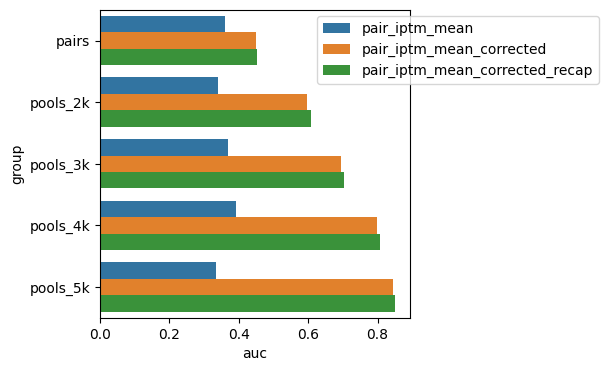

In [7]:
# Re-plot MGen pools-pairs data with original size-correction, and recap with default coefficients
plt.figure(figsize=(4, 4))
sns.barplot(aucs_, x='auc', y='group', hue='metric')
plt.legend(loc=(.7, .76))